# Neural Networks: From Architecture to Learning

**Companion notebook to Chapter 55 of *Modern Strain Gage Technology*.**

The chapter's worked example uses real fatigue data: the NASA Ames / Stanford **CFRP Composites** data set
(Saxena, Goebel, Larrosa and Chang, NASA Prognostics Data Repository). Notched T700G carbon-epoxy dogbone
coupons in three layups were fatigued in tension-tension at 5 Hz; at every stop a 12-element PZT network sent
Lamb waves along 36 actuator-sensor paths at 7 frequencies (252 signals per record), triaxial strain-gage
rosettes measured the coupon's stiffness, and X-rays recorded the damage.

This notebook asks one question of those data: **can a network read the strain-gage stiffness loss from the
Lamb waves alone, on a coupon it has never seen?** It compares a small neural network with two simpler
models (a regularized logistic regression and gradient-boosted trees), first with a careless record-level
split and then with whole coupons held out.

Figures produced (all at 300 dpi into `src/media/ch55/`):

- `fig55_nb1_cfrp_labels_inputs.png` - the stiffness-loss labels and the Lamb-wave damage index (Figure 55.1)
- `fig55_nb2_model_comparison.png` - random split vs. coupon held out, and the cutoff trade-off (Figure 55.2)
- `fig55_nb3_learning_curves.png` - training loss, leaky validation loss, held-out-coupon loss (Figure 55.3)

**Data.** The archive is 4.6 GB (`2. Composites.zip`, three nested `LayupN.zip` files). It is not stored in
the notebooks repository. Put it in `notebooks/data/cfrp/` (git-ignored), point the environment variable
`MSGT_CFRP_DIR` at a folder that holds it, or set `DOWNLOAD = True` below. The repository's terms ask users
to acknowledge the repository and the donors of the data; NASA and the donors assume no liability for its use.
The first run extracts Lamb-wave features from about 1,500 PZT records (a few minutes on a laptop) and caches
them; later runs take seconds.

In [1]:
# !pip install numpy scipy pandas matplotlib scikit-learn
import os, io, re, zipfile, urllib.request, pathlib, warnings
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, log_loss
from sklearn.model_selection import StratifiedKFold
%matplotlib inline
warnings.filterwarnings('ignore')

OUT_DIR = pathlib.Path('../src/media/ch55'); OUT_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'font.size': 10.5, 'axes.titlesize': 10.5, 'legend.fontsize': 9.8})   # drawn 7.5 in wide, printed at 6.25 in
STEEL, COPPER, GREEN, GRAY = '#3b6ea5', '#c8631b', '#2e8b57', '0.55'
NL = chr(10)

In [2]:
# ---- CFRP data access (shared by the Ch 55 and Ch 57 notebooks) ----
import os, io, re, zipfile, urllib.request, pathlib
import numpy as np, pandas as pd, scipy.io as sio

DATA_URL = "https://phm-datasets.s3.amazonaws.com/NASA/2.+Composites.zip"   # 4.6 GB
CFRP_DIR = pathlib.Path(os.environ.get("MSGT_CFRP_DIR", "data/cfrp")).expanduser()
DOWNLOAD = False   # set True to fetch the 4.6 GB archive automatically (one time)


def layup_zip(L):
    """Return an open ZipFile for Layup L (1-3), unpacking it from the archive if needed."""
    p = CFRP_DIR / f"Layup{L}.zip"
    if not p.exists():
        outer = CFRP_DIR / "Composites.zip"
        if not outer.exists():
            if not DOWNLOAD:
                raise FileNotFoundError(
                    f"CFRP data not found in {CFRP_DIR.resolve()}.\n"
                    f"Download {DATA_URL} (4.6 GB) into that folder, or set DOWNLOAD = True,\n"
                    "or point the MSGT_CFRP_DIR environment variable at an existing copy.")
            CFRP_DIR.mkdir(parents=True, exist_ok=True)
            print("downloading", DATA_URL, "(4.6 GB) ...")
            urllib.request.urlretrieve(DATA_URL, outer)
        with zipfile.ZipFile(outer) as z, z.open(f"2. Composites/Layup{L}.zip") as s, open(p, "wb") as o:
            while chunk := s.read(1 << 24):
                o.write(chunk)
    return zipfile.ZipFile(p)

---
## 1 - Lamb-wave features from the PZT network

Each PZT record holds 252 received waveforms (36 paths x 7 frequencies from 150 to 450 kHz, 2,000 samples
at 1.2 MHz). Every waveform is compared with the same path in the coupon's own baseline record, taken before
fatigue, and reduced to three numbers: a **damage index** (one minus the correlation coefficient), the
**energy ratio** (log10 of received energy over baseline energy) and the **time shift** that best aligns the
two (cross-correlation lag, in samples). That gives 756 features per record. Nothing here uses the strain
gages; they enter only as labels.

In [3]:
FEAT_CACHE = CFRP_DIR / 'derived' / 'ch55_lamb_features.csv.gz'
MAXLAG = 40                       # samples (33 us at 1.2 MHz)


def read_pzt(z, name):
    m = sio.loadmat(io.BytesIO(z.read(name)), squeeze_me=True, struct_as_record=False)
    c = m['coupon']
    S = np.array([p.signal_sensor for p in c.path_data], dtype=float)          # (252, 2000)
    key = [(int(p.actuator), int(p.sensor), int(p.frequency)) for p in c.path_data]
    sg = getattr(c, 'straingage_data', None)
    try:
        stiff = float(getattr(sg, 'stiffness_degradation', np.nan))
    except (TypeError, ValueError):
        stiff = np.nan                                                         # no strain-gage label
    num = lambda v: float(v) if np.size(v) == 1 else np.nan
    meta = dict(cycles=num(getattr(c, 'cycles', np.nan)), load=num(getattr(c, 'load', np.nan)),
                condition=str(getattr(c, 'condition', '')), stiff_label=stiff)
    return meta, key, S


def lamb_features(S, B):
    # Damage index, energy ratio and time shift of each path against its baseline.
    s = (S - S.mean(1, keepdims=True))[:, 100:]      # skip the actuation cross-talk
    b = (B - B.mean(1, keepdims=True))[:, 100:]
    rho = (s * b).sum(1) / np.sqrt((s * s).sum(1) * (b * b).sum(1) + 1e-30)
    eratio = np.log10((s * s).sum(1) / ((b * b).sum(1) + 1e-30) + 1e-30)
    n, best, lag_at = s.shape[1], np.full(len(s), -np.inf), np.zeros(len(s))
    for lag in range(-MAXLAG, MAXLAG + 1, 2):
        v = (s[:, lag:] * b[:, :n - lag]).sum(1) if lag >= 0 else (s[:, :lag] * b[:, -lag:]).sum(1)
        better = v > best
        best[better], lag_at[better] = v[better], lag
    return 1 - rho, eratio, lag_at


if not FEAT_CACHE.exists():
    rows = []
    for L in (1, 2, 3):
        z = layup_zip(L)
        names = [i.filename for i in z.infolist() if i.filename.endswith('.mat')
                 and '/._' not in i.filename and re.search(r'/PZT-?data/', i.filename)]
        for cp in sorted({n.split('/')[0] for n in names}):
            cn = [n for n in names if n.startswith(cp + '/')]
            base = [n for n in cn if re.search(r'_[01]_0\.mat$', n)]     # pre-fatigue baseline
            _, key0, B = read_pzt(z, sorted(base)[0])
            for n in cn:
                meta, key, S = read_pzt(z, n)
                if key != key0 or S.shape != B.shape:
                    continue
                di, er, lag = lamb_features(S, B)
                r = dict(coupon=cp.split('_F')[0].replace('_', ''), layup=L, file=n.split('/')[-1], **meta)
                for j, (a, s_, f) in enumerate(key):
                    r[f'di_{a}_{s_}_{f}'], r[f'er_{a}_{s_}_{f}'], r[f'lag_{a}_{s_}_{f}'] = di[j], er[j], lag[j]
                rows.append(r)
            print(cp, len(cn), 'records')
    FEAT_CACHE.parent.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(rows).to_csv(FEAT_CACHE, index=False)

feat = pd.read_csv(FEAT_CACHE)
feat['cond'] = feat.condition.str.lower().str.replace(' ', '').str[:4]
FEATS = [c for c in feat.columns if c.startswith(('di_', 'er_', 'lag_'))]
print(feat.shape[0], 'PZT records from', feat.coupon.nunique(), 'coupons;', len(FEATS), 'features each')

1495 PZT records from 12 coupons; 756 features each


---
## 2 - Labels from the strain gages (Figure 55.1)

The data set attaches to each PZT record the coupon's **stiffness loss measured by the strain gages** at that
stop (field `stiffness_degradation`). Only three coupons carry it: L1S11 and L1S12 (layup 1, [0₂/90₄]s) and
L2S11 (layup 2). The other nine coupons have Lamb waves and X-rays but no stiffness labels. We keep the
records taken with the coupon unloaded (clamped or traction-free), which match the unloaded baseline, and
bin the stiffness loss into three classes: below 3 %, 3 to 8 %, and 8 % or more.

y       < 3 %  3-8 %  >= 8 %
coupon                      
L1S11       7     19      39
L1S12       2     15      33
L2S11      14     16       4
inspection stops with labels: {'L1S11': 15, 'L1S12': 14, 'L2S11': 10}


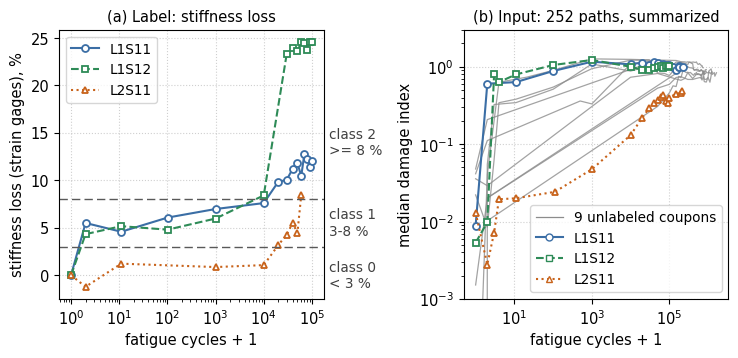

In [4]:
CUTS = (0.03, 0.08)
CLASS_NAMES = ['< 3 %', '3-8 %', '>= 8 %']
unloaded = feat[feat.cond.isin(['trac', 'clam', 'base'])].copy()
unloaded['di_med'] = unloaded[[c for c in FEATS if c.startswith('di_')]].median(axis=1)
lab = unloaded[unloaded.stiff_label.notna()].copy()
lab['y'] = np.digitize(lab.stiff_label, CUTS)
X, y, g = lab[FEATS].values, lab.y.values, lab.coupon.values
print(lab.groupby(['coupon', 'y']).size().unstack(fill_value=0).rename(columns=dict(enumerate(CLASS_NAMES))))
print('inspection stops with labels:', lab.groupby('coupon').cycles.nunique().to_dict())

STYLE = {'L1S11': dict(marker='o', ls='-', color=STEEL),
         'L1S12': dict(marker='s', ls='--', color=GREEN),
         'L2S11': dict(marker='^', ls=':', color=COPPER)}
fig, (a1, a2) = plt.subplots(1, 2, figsize=(7.5, 3.7))
for c, st in STYLE.items():
    d = lab[lab.coupon == c].groupby('cycles').stiff_label.first()
    a1.plot(d.index + 1, 100 * d.values, ms=5, lw=1.5, mfc='white', mew=1.3, label=c, **st)
for yv in (3, 8):
    a1.axhline(yv, color='0.35', lw=1, ls=(0, (6, 3)))
import matplotlib.transforms as mtrans
tr_ = mtrans.blended_transform_factory(a1.transAxes, a1.transData)
for yv, txt in ((0.0, 'class 0' + NL + '< 3 %'), (5.5, 'class 1' + NL + '3-8 %'), (14.0, 'class 2' + NL + '>= 8 %')):
    a1.text(1.02, yv, txt, transform=tr_, fontsize=9.8, color='0.25', va='center')
a1.set_xscale('log'); a1.set_xlabel('fatigue cycles + 1'); a1.set_ylabel('stiffness loss (strain gages), %')
a1.set_title('(a) Label: stiffness loss'); a1.legend(loc='upper left')
a1.grid(True, ls=':', alpha=0.6)

for c, d in unloaded.groupby('coupon'):
    m = d.groupby('cycles').di_med.median()
    if c in STYLE:
        a2.plot(m.index + 1, m.values, ms=5, lw=1.5, mfc='white', mew=1.3, zorder=3, **STYLE[c])
    else:
        a2.plot(m.index + 1, m.values, color=GRAY, lw=0.9, alpha=0.8, zorder=1)
a2.plot([], [], color=GRAY, lw=0.9, label='9 unlabeled coupons')
for c, st in STYLE.items():
    a2.plot([], [], ms=5, mfc='white', label=c, **st)
a2.set_xscale('log'); a2.set_yscale('log'); a2.set_ylim(1e-3, 3)
a2.set_xlabel('fatigue cycles + 1'); a2.set_ylabel('median damage index')
a2.set_title('(b) Input: 252 paths, summarized'); a2.legend(loc='lower right')
a2.grid(True, ls=':', alpha=0.6)
fig.tight_layout()
fig.savefig(OUT_DIR / 'fig55_nb1_cfrp_labels_inputs.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

---
## 3 - Three models and a clock, two ways of splitting (Figure 55.2)

* **Cycles only** (the clock): a logistic regression on log10(cycles + 1) and nothing else. Damage here only
  grows with time, so time in test is the baseline any damage model must beat (Chapter 54's advice to compare
  against a model given only the date).
* **Logistic regression** with strong L2 regularization: a linear model on the 756 standardized features.
* **Gradient boosting** (histogram trees, depth 3): the Chapter 54 baseline.
* **Neural network**: a multilayer perceptron with hidden layers of 64 and 32 ReLU units and a softmax output,
  with weight decay (`alpha = 1.0`); five random initializations, scores averaged.

Each is scored twice. The **random split** shuffles records into five folds, so records from the same coupon,
and often from the same inspection stop, sit on both sides. The **coupon held out** split trains on two
coupons and tests on the third, three times over. The score is balanced accuracy (the mean of the per-class
recalls; one in three is chance), computed per held-out coupon and pooled over all three.

model      clock  logistic  boosting  network
random      0.61      0.93      0.93     0.93
held_out    0.61      0.81      0.68     0.77
ba_L1S11    0.95      0.88      0.74     0.85
acc_L1S11   0.95      0.92      0.88     0.91
ba_L1S12    0.80      0.88      0.84     0.89
acc_L1S12   0.78      0.84      0.78     0.86
ba_L2S11    0.33      0.41      0.29     0.30
acc_L2S11   0.12      0.53      0.38     0.38
network held-out balanced accuracy over 5 seeds: min 0.71, max 0.80
majority-class accuracy per coupon: {'L1S11': 0.6, 'L1S12': 0.66, 'L2S11': 0.47}
network confusion matrix, coupons held out (rows = true class):
[[21  2  0]
 [19 27  4]
 [ 4  4 68]]
median damage index alone, coupons held out: balanced accuracy 0.45
cutoff 0.7: sensitivity 0.82, false alarms 0.04
cutoff 0.5: sensitivity 0.82, false alarms 0.09
cutoff 0.3: sensitivity 0.82, false alarms 0.17
cutoff 0.2: sensitivity 0.83, false alarms 0.35
misses at cutoff 0.2, by coupon: {'L2S11': 19, 'L1S12': 3}


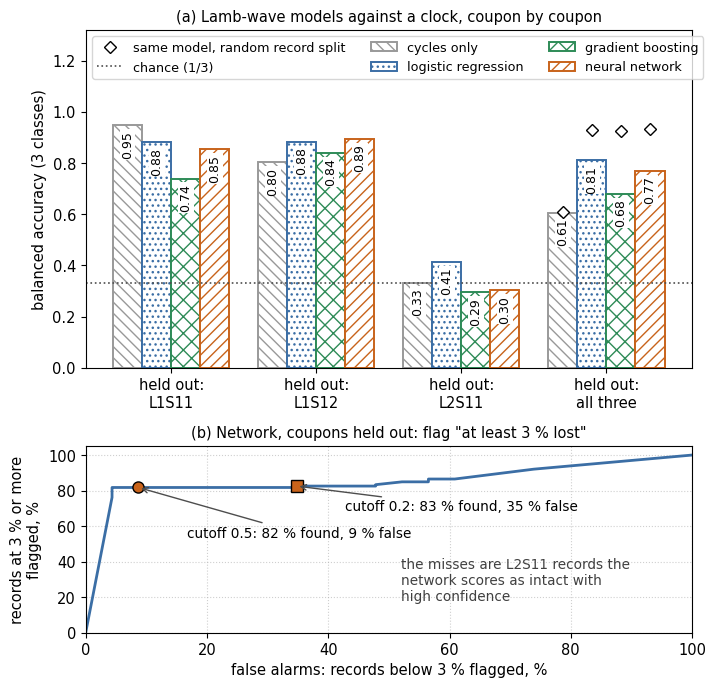

In [5]:
SEEDS = range(5)
COUPONS = ['L1S11', 'L1S12', 'L2S11']

def make(name, seed=0):
    if name == 'clock':        # time in test only: log10(cycles + 1)
        return make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=5000))
    if name == 'logistic':
        return make_pipeline(StandardScaler(), LogisticRegression(C=0.05, max_iter=5000))
    if name == 'boosting':
        return HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=200, random_state=seed)
    return make_pipeline(StandardScaler(),
                         MLPClassifier(hidden_layer_sizes=(64, 32), alpha=1.0, max_iter=2000, random_state=seed))

x_clock = np.log10(lab[['cycles']].values + 1)
rows, proba_net = [], np.zeros((len(y), 3))
for name in ['clock', 'logistic', 'boosting', 'network']:
    Xm = x_clock if name == 'clock' else X
    for seed in (SEEDS if name in ('boosting', 'network') else [0]):
        p_rand = np.zeros(len(y), int)
        for tr, te in StratifiedKFold(5, shuffle=True, random_state=seed).split(Xm, y):
            p_rand[te] = make(name, seed).fit(Xm[tr], y[tr]).predict(Xm[te])
        p_held = np.zeros(len(y), int)
        for c in COUPONS:                                         # leave one coupon out
            tr, te = g != c, g == c
            m = make(name, seed).fit(Xm[tr], y[tr])
            p_held[te] = m.predict(Xm[te])
            if name == 'network':
                proba_net[te] += m.predict_proba(Xm[te]) / len(SEEDS)
        r = dict(model=name, seed=seed, random=balanced_accuracy_score(y, p_rand),
                 held_out=balanced_accuracy_score(y, p_held))
        for c in COUPONS:
            r['ba_' + c] = balanced_accuracy_score(y[g == c], p_held[g == c])
            r['acc_' + c] = np.mean(p_held[g == c] == y[g == c])
        rows.append(r)
runs = pd.DataFrame(rows)
res = runs.groupby('model').mean(numeric_only=True).drop(columns='seed').loc[['clock', 'logistic', 'boosting', 'network']]
print(res.round(2).T)
print('network held-out balanced accuracy over 5 seeds: min %.2f, max %.2f'
      % (runs[runs.model == 'network'].held_out.min(), runs[runs.model == 'network'].held_out.max()))
print('majority-class accuracy per coupon:', {c: round(np.bincount(y[g == c]).max() / (g == c).sum(), 2) for c in COUPONS})
print('network confusion matrix, coupons held out (rows = true class):')
print(confusion_matrix(y, proba_net.argmax(1)))

# One-feature baseline: the median damage index alone
p1 = np.zeros(len(y), int)
x1 = np.log10(lab[['di_med']].values + 1e-4)
for c in COUPONS:
    p1[g == c] = make('logistic').fit(x1[g != c], y[g != c]).predict(x1[g == c])
print('median damage index alone, coupons held out: balanced accuracy %.2f' % balanced_accuracy_score(y, p1))

# Cutoff trade-off for flagging 'at least 3 % stiffness loss' (classes 1 + 2)
p_dmg, is_dmg = proba_net[:, 1:].sum(1), y >= 1
cuts = np.linspace(0.0, 1.0, 101)
sens = np.array([(p_dmg[is_dmg] >= k).mean() for k in cuts])
fa = np.array([(p_dmg[~is_dmg] >= k).mean() for k in cuts])
for k in (0.7, 0.5, 0.3, 0.2):
    print(f'cutoff {k:.1f}: sensitivity {(p_dmg[is_dmg] >= k).mean():.2f}, false alarms {(p_dmg[~is_dmg] >= k).mean():.2f}')
missed = is_dmg & (p_dmg < 0.2)
print('misses at cutoff 0.2, by coupon:', pd.Series(g[missed]).value_counts().to_dict())

fig, (a1, a2) = plt.subplots(2, 1, figsize=(7.5, 7.0), gridspec_kw={'height_ratios': [1.45, 0.8]})
MODELS = [('clock', 'cycles only', '0.6', '\\\\\\'), ('logistic', 'logistic regression', STEEL, '...'),
          ('boosting', 'gradient boosting', GREEN, 'xx'), ('network', 'neural network', COPPER, '///')]
groups = ['held out:' + NL + c for c in COUPONS] + ['held out:' + NL + 'all three']
xs = np.arange(4); w = 0.2
for j, (k, lbl, col, hatch) in enumerate(MODELS):
    vals = [res.loc[k, 'ba_' + c] for c in COUPONS] + [res.loc[k, 'held_out']]
    a1.bar(xs + (j - 1.5) * w, vals, w, color='white', edgecolor=col, hatch=hatch, lw=1.4, label=lbl)
    for xi, v in zip(xs, vals):
        a1.text(xi + (j - 1.5) * w, v - 0.02, f'{v:.2f}', ha='center', fontsize=9.0, rotation=90, va='top',
                bbox=dict(boxstyle='square,pad=0.1', fc='white', ec='none'))
    a1.plot(3 + (j - 1.5) * w, res.loc[k, 'random'], 'D', color='black', mfc='white', ms=6, zorder=5)
a1.plot([], [], 'D', color='black', mfc='white', ms=6, label='same model, random record split')
a1.axhline(1/3, color='0.3', ls=':', lw=1.2, label='chance (1/3)')
a1.set_xticks(xs); a1.set_xticklabels(groups); a1.set_ylim(0, 1.32)
a1.set_ylabel('balanced accuracy (3 classes)')
a1.set_title('(a) Lamb-wave models against a clock, coupon by coupon')
a1.legend(loc='upper left', ncol=3, fontsize=9.2, frameon=True)

a2.plot(100 * fa, 100 * sens, color=STEEL, lw=2.0)
for k, mk in ((0.5, 'o'), (0.2, 's')):
    i = np.argmin(np.abs(cuts - k))
    a2.plot(100 * fa[i], 100 * sens[i], mk, color=COPPER, ms=8, mec='black')
    a2.annotate(f'cutoff {k:.1f}: {100*sens[i]:.0f} % found, {100*fa[i]:.0f} % false', xy=(100 * fa[i], 100 * sens[i]),
                xytext=(100 * fa[i] + 8, 100 * sens[i] - (28 if k == 0.5 else 14)), fontsize=9.8,
                arrowprops=dict(arrowstyle='->', color='0.3'))
a2.text(52, 18, 'the misses are L2S11 records the' + NL + 'network scores as intact with' + NL + 'high confidence', fontsize=9.8, color='0.25')
a2.set_xlim(0, 100); a2.set_ylim(0, 105)
a2.set_xlabel('false alarms: records below 3 % flagged, %'); a2.set_ylabel('records at 3 % or more' + NL + 'flagged, %')
a2.set_title('(b) Network, coupons held out: flag "at least 3 % lost"'); a2.grid(True, ls=':', alpha=0.6)
fig.tight_layout()
fig.savefig(OUT_DIR / 'fig55_nb2_model_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

---
## 4 - Learning curves, honest and leaky (Figure 55.3)

The network is trained epoch by epoch on the two layup-1 coupons. Three losses are recorded after every
epoch: on the training records, on a random 20 % of records from the *same two coupons* held back as a
validation set (the leaky choice), and on the coupon the network never sees, L2S11.

leaky validation minimum at epoch 184 ; held-out-coupon minimum at epoch 2
final losses: {'train': 0.013, 'leaky': 0.046, 'held': 2.052}
lowest leaky validation loss 0.039 at epoch 184; patience-10 rule stops at epoch 21
held-out loss at its best 1.23, uniform guess ln 3 = 1.10
records per training pass: 92 (one mini-batch, so one Adam step per epoch)


validation by coupon (train L1S11, validate L1S12): minimum at epoch 3


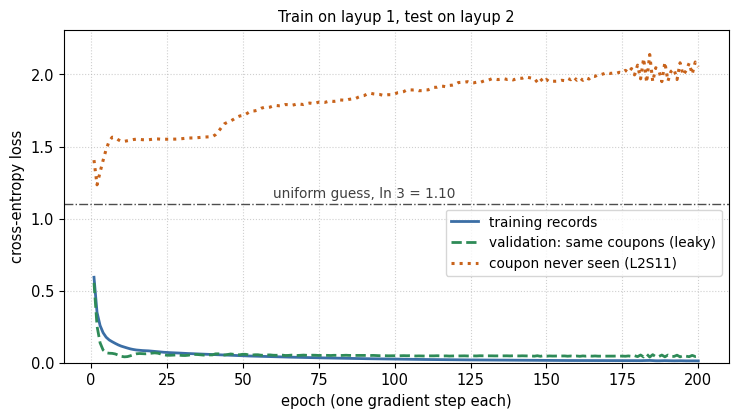

In [6]:
from sklearn.model_selection import train_test_split
tr_all, test = g != 'L2S11', g == 'L2S11'
idx = np.where(tr_all)[0]
i_tr, i_va = train_test_split(idx, test_size=0.2, random_state=0, stratify=y[idx])
sc = StandardScaler().fit(X[i_tr])
net = MLPClassifier(hidden_layer_sizes=(64, 32), alpha=1.0, learning_rate_init=1e-3, random_state=0)
curves = {'train': [], 'leaky': [], 'held': []}
for epoch in range(200):
    net.partial_fit(sc.transform(X[i_tr]), y[i_tr], classes=[0, 1, 2])
    for k, ii in (('train', i_tr), ('leaky', i_va), ('held', np.where(test)[0])):
        curves[k].append(log_loss(y[ii], net.predict_proba(sc.transform(X[ii])), labels=[0, 1, 2]))
best_leaky, best_held = int(np.argmin(curves['leaky'])), int(np.argmin(curves['held']))
print('leaky validation minimum at epoch', best_leaky + 1, '; held-out-coupon minimum at epoch', best_held + 1)
print('final losses:', {k: round(v[-1], 3) for k, v in curves.items()})

# Patience-based early stopping on the leaky curve (sklearn's default: 10 epochs without improvement)
best, wait, stop = np.inf, 0, None
for e, v in enumerate(curves['leaky']):
    if v < best - 1e-4:
        best, wait = v, 0
    else:
        wait += 1
        if wait >= 10:
            stop = e + 1; break
print('lowest leaky validation loss %.3f at epoch %d; patience-10 rule stops at epoch %s'
      % (min(curves['leaky']), best_leaky + 1, stop))
print('held-out loss at its best %.2f, uniform guess ln 3 = %.2f' % (min(curves['held']), np.log(3)))
print('records per training pass:', len(i_tr), '(one mini-batch, so one Adam step per epoch)')

# Validation split by coupon: train on L1S11, validate on L1S12
a_, b_ = g == 'L1S11', g == 'L1S12'
sc2 = StandardScaler().fit(X[a_])
net2 = MLPClassifier(hidden_layer_sizes=(64, 32), alpha=1.0, learning_rate_init=1e-3, random_state=0)
val_coupon = []
for epoch in range(200):
    net2.partial_fit(sc2.transform(X[a_]), y[a_], classes=[0, 1, 2])
    val_coupon.append(log_loss(y[b_], net2.predict_proba(sc2.transform(X[b_])), labels=[0, 1, 2]))
print('validation by coupon (train L1S11, validate L1S12): minimum at epoch', int(np.argmin(val_coupon)) + 1)

fig, ax = plt.subplots(figsize=(7.5, 4.3))
ep = np.arange(1, 201)
ax.plot(ep, curves['train'], color=STEEL, lw=2.0, ls='-', label='training records')
ax.plot(ep, curves['leaky'], color=GREEN, lw=2.0, ls='--', label='validation: same coupons (leaky)')
ax.plot(ep, curves['held'], color=COPPER, lw=2.2, ls=':', label='coupon never seen (L2S11)')
ax.axhline(np.log(3), color='0.3', lw=1.0, ls='-.')
ax.text(60, np.log(3) + 0.05, 'uniform guess, ln 3 = 1.10', ha='left', fontsize=9.8, color='0.25')
ax.set_xlabel('epoch (one gradient step each)'); ax.set_ylabel('cross-entropy loss'); ax.set_ylim(0, max(curves['held']) * 1.08)
ax.set_title('Train on layup 1, test on layup 2'); ax.legend(loc='center right', bbox_to_anchor=(1.0, 0.36)); ax.grid(True, ls=':', alpha=0.6)
fig.tight_layout()
fig.savefig(OUT_DIR / 'fig55_nb3_learning_curves.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

---
## Where to take this next

1. **Add the nine unlabeled coupons.** Their MTS files record load and crosshead displacement, from which a
   cruder stiffness can be computed; labels for more coupons, and more layups, are the one change most likely
   to move the held-out score.
2. **Look at what the network uses.** Permutation importance by path and frequency shows whether the network
   leans on paths that cross the notch, where the X-rays show the damage, or on paths near the PZT strips,
   whose bonds and wiring degraded during the tests.
3. **Calibrate the scores.** Fit temperature scaling on two coupons and check a reliability diagram on the third
   (Chapter 60). Expect the overconfidence on L2S11 to survive calibration: no rescaling fixes a model that has
   never seen the layup.